# 范数
- torch.norm(A, p='fro')    # Frobenius 范数
- torch.norm(A, p=2, dim=1) # 沿 dim=1 的 L2 范数

在 PyTorch 中，<font color='red'>torch.norm 是用于计算张量（Tensor）范数的核心函数</font>

你提到的这两种用法，
- 分别代表了**矩阵范数**和**向量范数**两种截然不同的计算逻辑。

下面为你详细拆解：

## torch.norm(A, p='fro')：Frobenius 范数（矩阵范数）

In [2]:
from IPython.display import Image

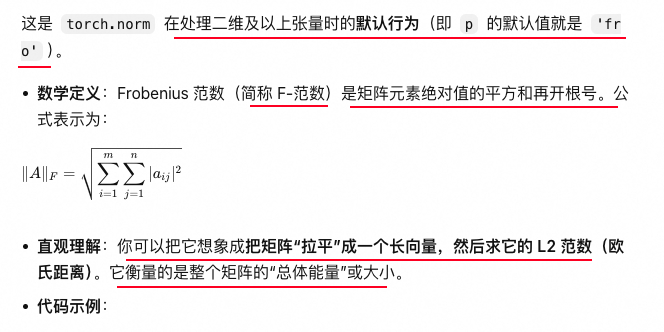

In [3]:
Image(filename='./Image/f_norm.png')

In [ ]:
import torch
A = torch.tensor([[1.0, 2.0], 
                  [3.0, 4.0]])
norm_fro = torch.norm(A, p='fro') 
# 计算过程: sqrt(1^2 + 2^2 + 3^2 + 4^2) = sqrt(30) ≈ 5.4772

- ⚠️ 核心避坑：
  - 矩阵范数（如 'fro' 或核范数 'nuc'）**不能与 dim 参数混用**。如果你写 torch.norm(A, p='fro', dim=1)，PyTorch 会直接报错，<font color='red'>因为矩阵范数是对整个矩阵进行降维的，不能指定沿某个轴计算</font>。

In [ ]:
Image(filename='./Image/f_norm_1.png')

## torch.norm(A, p=2, dim=1)：沿 dim=1 的 L2 范数（向量范数）

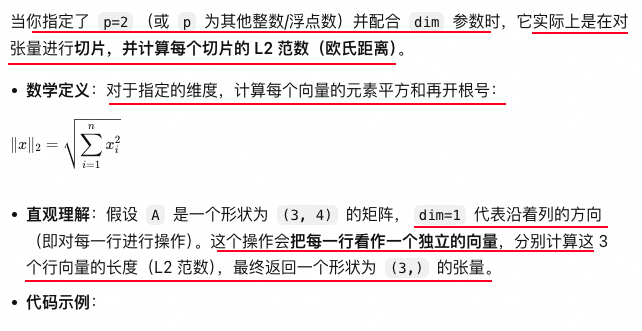

In [4]:
Image(filename='./Image/l2_norm.png')

In [ ]:
A = torch.tensor([[1.0, 2.0, 3.0], 
                  [4.0, 5.0, 6.0]])
norm_l2 = torch.norm(A, p=2, dim=1)
# 第一行: sqrt(1^2 + 2^2 + 3^2) = sqrt(14) ≈ 3.7417
# 第二行: sqrt(4^2 + 5^2 + 6^2) = sqrt(77) ≈ 8.7750
# 输出: tensor([3.7417, 8.7750])

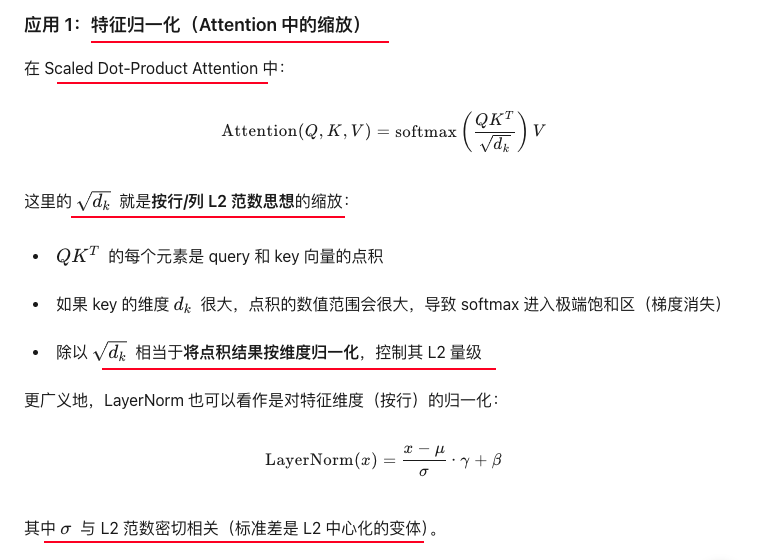

In [5]:
Image(filename='./Image/l2_norm_1.png')

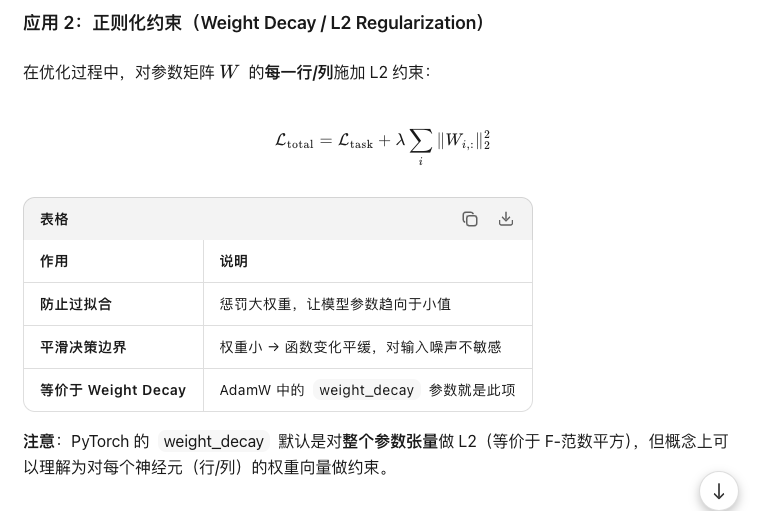

In [6]:
Image(filename='./Image/l2_norm_2.png')


**注意：**
- PyTorch 的 weight_decay 默认是对整个参数张量做 L2（等价于 F-范数平方），**但概念上可以理解为对每个神经元（行/列）的权重向量做约束**。

- 关于 keepdim 参数：
  - 默认情况下 keepdim=False，计算后指定的 dim 维度会被“压缩”（消失）。
  - 如果你希望保持原始维度结构（例如为了后续能直接做矩阵广播相除），**可以加上 keepdim=True，此时输出形状会变为 (3, 1)。**

## 总结对比

| 特性 | `p='fro'` (Frobenius 范数) | `p=2, dim=1` (L2 向量范数) |
| :--- | :--- | :--- |
| 计算对象 | 整个矩阵的所有元素 | <font color='red'>沿指定维度切分出的每个子向量</font> |
| 输出形状 | 标量（整个矩阵的范数） | 降维后的张量（如 `(m,)`） |
| 几何意义 | 矩阵整体的“能量”或大小 | **每个行向量在空间中的欧氏长度** |
| 能否指定 dim | 绝对不能 | 必须指定（否则默认全局计算） |


|                 | F-范数              | 按行/列 L2 范数           |
| :-------------- | :---------------- | :------------------- |
| **输出形状**        | 标量（一个数）           | 向量（每行/列一个数）          |
| **计算范围**        | 整个矩阵所有元素          | 局部（逐行或逐列）            |
| **用途**          | 衡量**整体误差**        | 控制**局部特征尺度**         |
| **在 Loss 中的角色** | 通常是**主损失**（如重建损失） | 通常是**正则项**或**预处理步骤** |
| **是否保持结构**      | 否（展平后信息丢失）        | 是（保留行/列独立性）          |


| 概念          | 类比                                  |
| :---------- | :---------------------------------- |
| **F-范数**    | <font color='red'>像用"总重量"衡量一个包裹——把所有东西加起来看整体</font>          |
| **行 L2 范数** | <font color='blue'>像检查包裹里**每个小盒子**的重量是否超标——单独约束，保持盒间独立</font> |


在深度学习中，
- **F-范数常用于衡量两个矩阵（如真实值与预测值）之间的重构误差**；
- 而按行/列计算的 L2 范数则广泛应用于特征归一化（如 Attention 机制中的缩放）和正则化约束中。

## 一句话总结
- F-范数回答"整体差了多少"（全局重构误差），
- 行/列 L2 范数回答"每个特征/神经元是否规矩"（局部归一化与正则）。
- <font color='blue'>前者是损失函数的主角，后者是训练稳定的幕后调控者</font>。

# 强化学习与范数的使用

强化学习中范数的使用贯穿**梯度控制**、**策略约束**、**价值估计**、**参数正则**化等多个环节。下面按场景系统梳理：

## 梯度范数：防止爆炸，稳定训练
### 梯度裁剪（Gradient Clipping）


In [ ]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

##### 为什么 RL 中比 SL 更刚需？

| 场景     | 梯度来源                                               | 风险                     |
| :----- | :------------------------------------------------- | :--------------------- |
| **SL** | 固定数据集的交叉熵/MSE                                      | 梯度有界，相对稳定              |
| **RL** | $\nabla \log \pi \cdot A \cdot \rho$（优势 × 重要性采样比率） | 优势噪声大、$\rho$ 可能极大，梯度无界 |


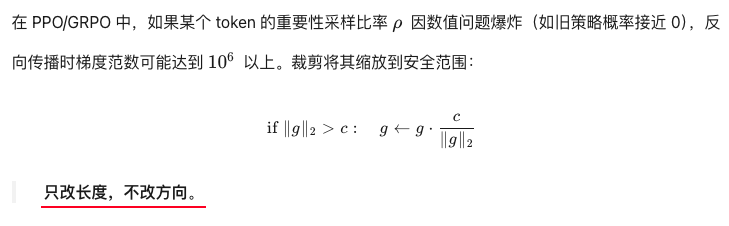

In [7]:
Image(filename='./Image/f_clip.png')

## 策略距离：KL 散度与概率分布的"范数"
虽然 KL 散度严格来说不是范数（不满足对称性和三角不等式），但在 RL 中它被当作分布间的"距离度量"使用：

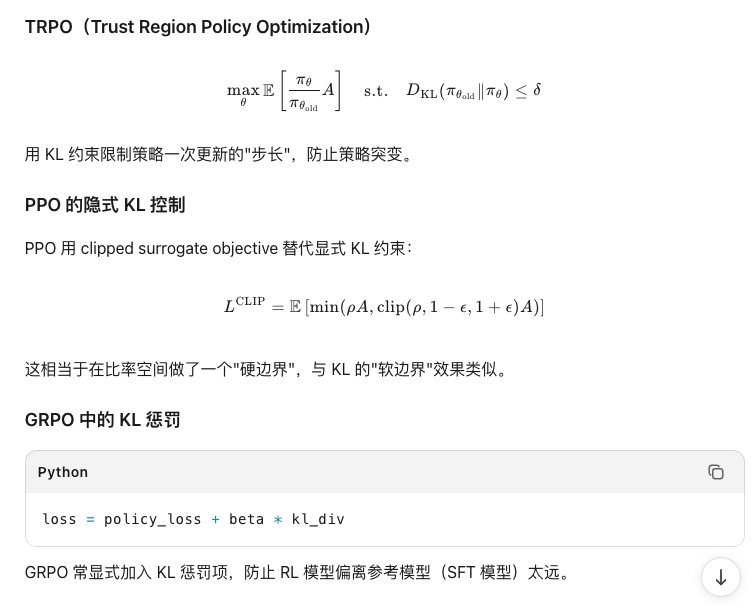

In [8]:
Image(filename='./Image/po_distance.png')

## 价值函数：L2/F-范数损失

Critic（价值网络）的损失通常是均方误差（MSE），即预测值与回报之差的 L2 范数：

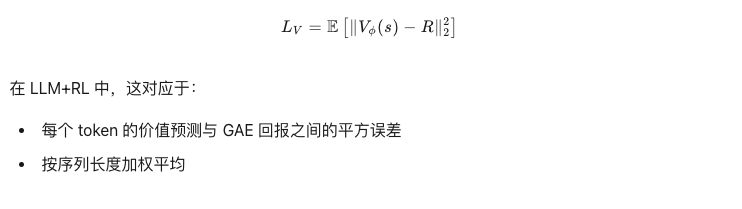

In [9]:
Image(filename='./Image/f_loss.png')

## 参数正则化：L2 Weight Decay

In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

**作用**：惩罚大权重，防止策略过拟合到训练任务的特定模式上。
在 RLHF 中尤为重要：
  - 没有 weight decay，RL 可能把某些 token 的概率推到极端（如 0.9999），导致探索丧失
  - L2 正则保持参数"小且分散"，维持一定的输出熵

## 状态/动作空间的范数
### 连续动作空间的裁剪
在机器人控制等连续动作域中：

$a=clip(π_θ(s),a_{min},a_{max})$

或用 tanh 将动作约束在单位范数球内。

### 状态归一化（Running Statistics）

In [ ]:
# 维护运行均值和标准差
normalized_state = (state - running_mean) / (running_std + 1e-8)

这本质上是按特征维度做 L2 标准化的变体，稳定价值函数的学习。

## LLM+RL 中的特殊范数用法

结合最近几篇论文，范数在 LLM 强化学习中有更精细的用法：

### 梯度范数的结构性偏差
《Do Not Let Low-Probability Tokens Over-Dominate》揭示：

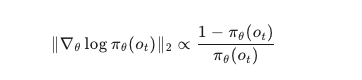

In [10]:
Image(filename='./Image/f_rl_1.png')

低概率 token 的梯度范数极大，高概率 token 的梯度范数极小。这促使研究者设计：
- Advantage Reweighting：按概率压缩低概率 token 的优势
- Lopti：隔离更新，避免低概率梯度淹没高概率梯度

### 优势归一化（Batch-Level Normalization）
GRPO/DAPO 中的标准操作：

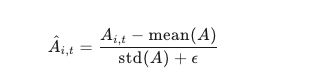

In [11]:
Image(filename='./Image/f_rl_2.png')

这本质上是对优势值做 L2 标准化（减去均值除以标准差），消除 batch 间优势尺度的波动。

### 概率感知重加权
《On the Direction of RLVR Updates》提出的：

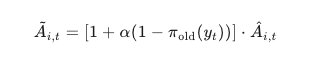

In [12]:
Image(filename='./Image/f_rl_3.png')

虽然不是直接的范数操作，但其设计动机与概率空间的距离度量密切相关——低概率 token 离分布中心"更远"，需要不同的权重。

## 范数在 RL 中的角色总结

| 层级     | 范数类型    | 作用                       |
| :----- | :------ | :----------------------- |
| **梯度** | L2 范数   | 控制更新步长，防止爆炸              |
| **策略** | KL 散度   | 约束策略变化幅度，保持稳定性           |
| **价值** | L2/F 范数 | 衡量预测误差，监督 Critic 学习      |
| **参数** | L2 范数   | 正则化，防止过拟合                |
| **特征** | L2 标准化  | 归一化状态/优势，稳定训练            |
| **分析** | 梯度范数    | 诊断 token 级更新偏差（如低概率主导问题） |


## 一句话总结
在强化学习中，范数是"控制尺度"的核心工具——梯度范数控制学习的速度，KL 控制策略偏移的距离，L2 损失控制价值估计的精度，Weight Decay 控制模型的复杂度。没有这些范数约束，RL 的高方差特性会让训练迅速失控。